In [2]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr

sys.path.append(str(Path.cwd().parent))
from utils.helpers import load_data

### This files creates analysis of the overall performance among students on the exam for each gender and combined.

In [3]:
df = load_data("../data/cleaned_data/IN1020_2024_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN1020_2024_cleaned_data.csv
Shape: (65880, 14)


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,candidate_response_text,total_score
0,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_1368096164456,Heksadesimale tall,71.61
1,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA172399520449584402464-f255-46e6...,Oktale tall,71.61
2,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA17239952044953d28e157-ac4c-49db...,Titallsystemet,71.61
3,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA1723995204495960f601e-73d5-48f8...,Heksadesimale tall,71.61
4,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA17239952636882cb13f25-bd73-4352...,Titallsystemet,71.61


In [4]:
df_combined = df.groupby('student_id').agg({
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

df_male = df_combined[df_combined['gender'] == 'M']
df_female = df_combined[df_combined['gender'] == 'F']

In [5]:
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)

df_time.head()

,student_id,exam_start_time,exam_end_time,gender,total_score,time_taken
0,1,2024-12-11 14:01:44,2024-12-11 16:18:42,M,72.63,136.97
1,2,2024-12-11 14:00:02,2024-12-11 17:52:41,F,56.71,232.65
2,3,2024-12-11 14:00:03,2024-12-11 17:57:49,M,75.45,237.77
3,4,2024-12-11 14:00:05,2024-12-11 17:53:27,F,55.88,233.37
4,5,2024-12-11 14:00:04,2024-12-11 17:23:20,M,72.28,203.27


In [6]:
# Combined descriptive statistics table
descriptive_stats = pd.DataFrame({
    'Combined': round(df_combined['total_score'].describe(), 2),
    'Male': round(df_male['total_score'].describe(), 2),
    'Female': round(df_female['total_score'].describe(), 2)
})

# Add median row explicitly
median_row = pd.DataFrame({
    'Combined': [round(df_combined['total_score'].median(), 2)],
    'Male': [round(df_male['total_score'].median(), 2)],
    'Female': [round(df_female['total_score'].median(), 2)]
}, index=['median'])

# Add mode row
mode_row = pd.DataFrame({
    'Combined': [round(df_combined['total_score'].mode()[0], 2)],
    'Male': [round(df_male['total_score'].mode()[0], 2)],
    'Female': [round(df_female['total_score'].mode()[0], 2)]
}, index=['mode'])

std_row = pd.DataFrame({
    'Combined': [round(df_combined['total_score'].std(), 2)],
    'Male': [round(df_male['total_score'].std(), 2)],
    'Female': [round(df_female['total_score'].std(), 2)]
}, index=['std'])

# Combine the tables
descriptive_stats = pd.concat([descriptive_stats, median_row, mode_row, std_row])

print("Descriptive Statistics for Total Score:")
descriptive_stats

Descriptive Statistics for Total Score:


,Combined,Male,Female
count,569.00,311.00,258.00
mean,64.88,66.07,63.44
std,13.83,13.33,14.30
min,24.48,27.70,24.48
25%,56.10,58.14,53.81
50%,67.11,67.93,66.66
75%,74.88,75.62,74.14
max,91.85,91.85,90.89
median,67.11,67.93,66.66
mode,63.53,63.53,42.50


### Skewness

<Figure size 1200x800 with 0 Axes>

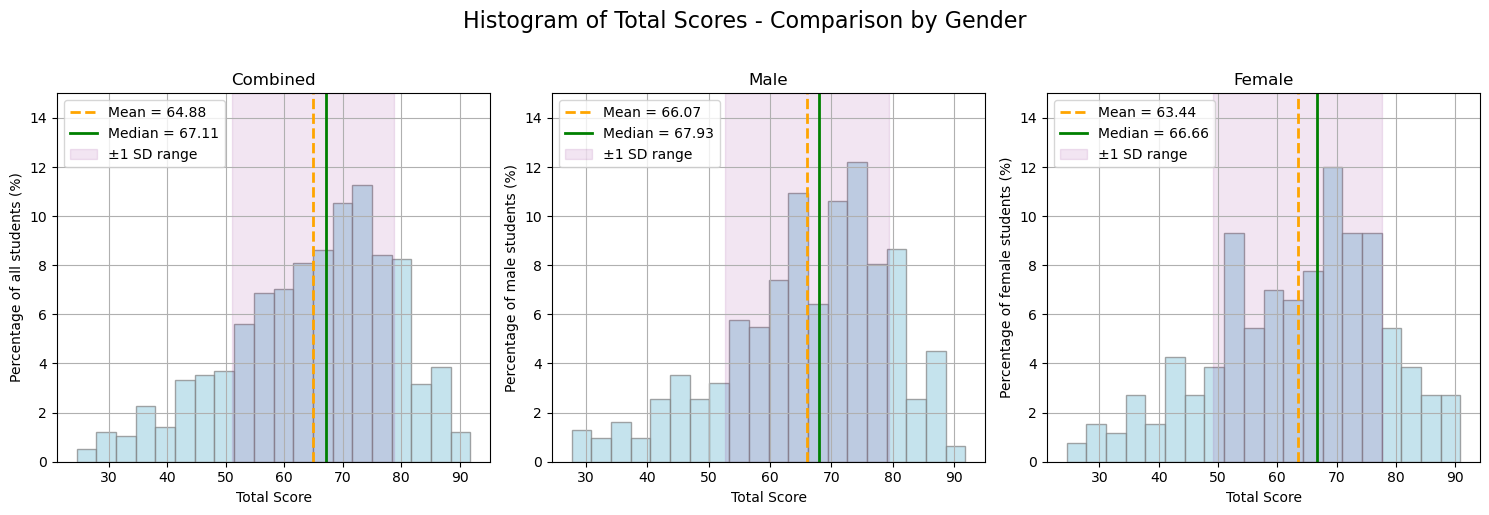

In [7]:
def plot_score_distributions(df, axes, title, ylabel):
    std_combined = round(df['total_score'].std(), 2)
    total_students = len(df)
    axes.hist(df['total_score'], bins=20, color='lightblue', edgecolor='gray', alpha=0.7, weights=np.ones(len(df))/total_students*100)
    axes.axvline(round(df['total_score'].mean(), 2), color='orange', linestyle='--', linewidth=2, label=f'Mean = {round(df["total_score"].mean(), 2)}')
    axes.axvline(round(df['total_score'].median(), 2), color='green', linestyle='-', linewidth=2, label=f'Median = {round(df["total_score"].median(), 2)}')
    axes.axvspan(df['total_score'].mean() - std_combined, df['total_score'].mean() + std_combined, color='purple', alpha=0.1, label='±1 SD range')
    axes.set_xlabel("Total Score")
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.grid(True)
    axes.set_ylim(0, 15)
    axes.legend()

# Combined histogram plot for all three groups with percentage on y-axis
plt.figure(figsize=(12, 8))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Combined histogram - percentage of all students
plot_score_distributions(df_combined, axes[0], "Combined", "Percentage of all students (%)")

# Male histogram - percentage of male students
plot_score_distributions(df_male, axes[1], "Male", "Percentage of male students (%)")

# Female histogram - percentage of female students
plot_score_distributions(df_female, axes[2], "Female", "Percentage of female students (%)")

plt.suptitle("Histogram of Total Scores - Comparison by Gender", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Outliers

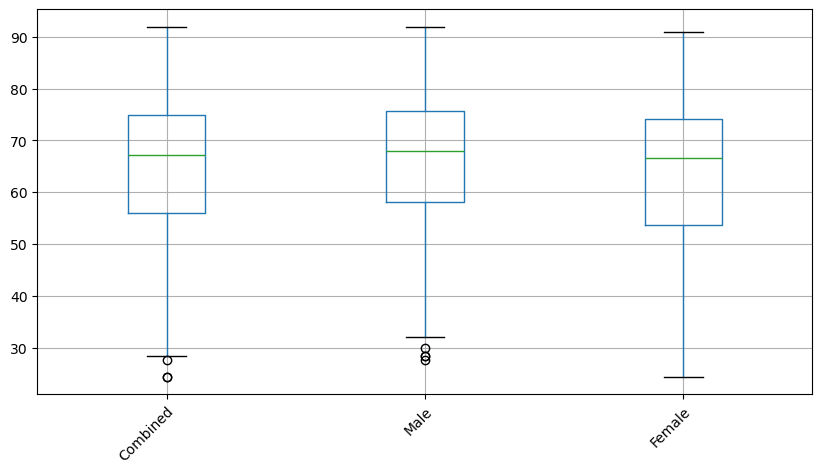

In [8]:
# Boxplot to visualize outliers among points
plt.figure(figsize=(10, 5))
df_outliers = pd.DataFrame({
    'Combined': df_combined['total_score'],
    'Male': df_male['total_score'],
    'Female': df_female['total_score']
})
df_outliers.boxplot()
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.show()

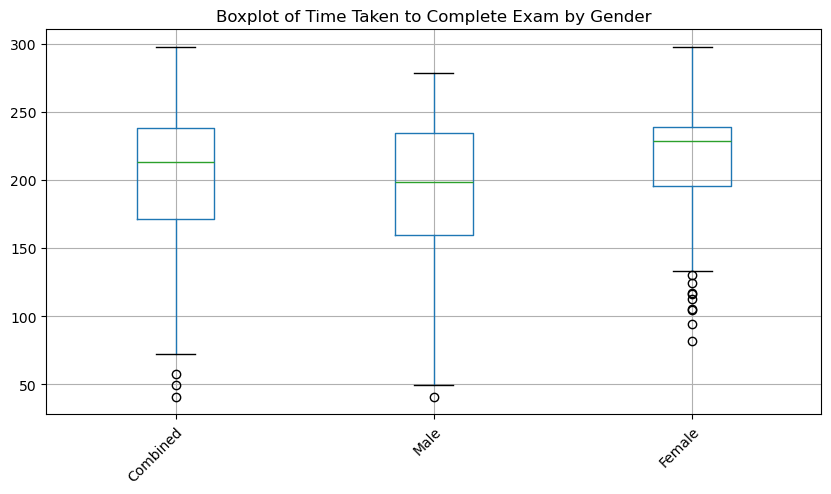

In [9]:
# Boxplot to visualize outliers among time taken
plt.figure(figsize=(10, 5))
df_time_outliers = pd.DataFrame({
    'Combined': df_time['time_taken'],
    'Male': df_time[df_time['gender'] == 'M']['time_taken'],
    'Female': df_time[df_time['gender'] == 'F']['time_taken']
})
df_time_outliers.boxplot()
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title("Boxplot of Time Taken to Complete Exam by Gender")
plt.show()  

In [10]:
# Pearson correlation between time taken and total score
correlation, p_value = pointbiserialr(df_time['total_score'], df_time['time_taken'])
print(f"Pearson correlation between time taken and total score: {correlation:.4f} (p-value: {p_value:.2f})")


Pearson correlation between time taken and total score: -0.0839 (p-value: 0.05)


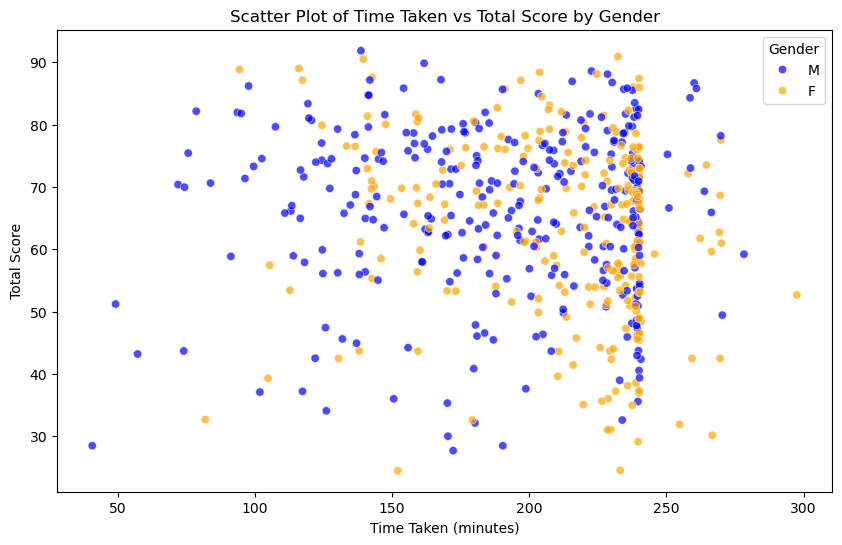

In [11]:
#scatter plot time taken vs total score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_time, x='time_taken', y='total_score', hue='gender', alpha=0.7, palette={'F': 'orange', 'M': 'blue'})
plt.title("Scatter Plot of Time Taken vs Total Score by Gender")
plt.xlabel("Time Taken (minutes)")
plt.ylabel("Total Score")
plt.legend(title='Gender')
plt.show()

/var/folders/14/203xxcn538322g5z2h7l50fm0000gn/T/ipykernel_61442/4084575939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='time_taken', data=df_time, palette={'F': 'orange', 'M': 'lightblue'})


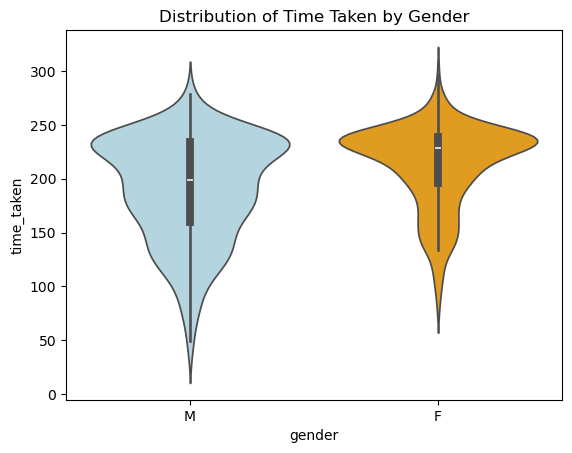

In [15]:
# Violin plot of time by gender
sns.violinplot(x='gender', y='time_taken', data=df_time, palette={'F': 'orange', 'M': 'lightblue'})
plt.title('Distribution of Time Taken by Gender')
plt.show()

/var/folders/14/203xxcn538322g5z2h7l50fm0000gn/T/ipykernel_61442/1077389414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='total_score', data=df_combined, palette={'F': 'orange', 'M': 'lightblue'})


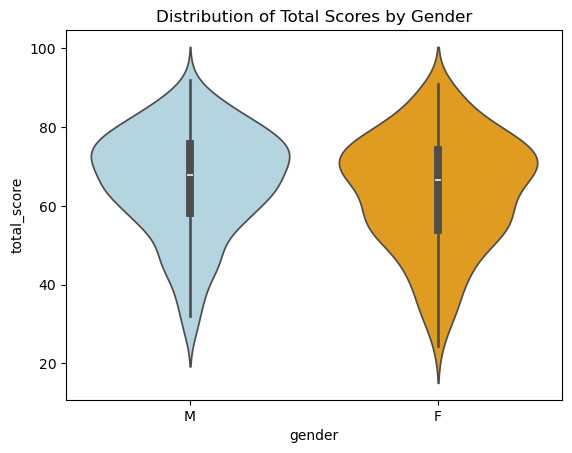

In [16]:
# Violin plot of total scores by gender
sns.violinplot(x='gender', y='total_score', data=df_combined, palette={'F': 'orange', 'M': 'lightblue'})
plt.title('Distribution of Total Scores by Gender')
plt.show()

### Correlation between gender and total score

In [14]:
#point-biserial correlation between gender and total score

# Prepare the data
df_combined['gender_numeric'] = df_combined['gender'].map({'M': 1, 'F': 0})
male_scores = df_combined[df_combined['gender'] == 'M']['total_score']
female_scores = df_combined[df_combined['gender'] == 'F']['total_score']

# Calculate point-biserial correlation
corr, p_value = pointbiserialr(df_combined['gender_numeric'], df_combined['total_score'])
print(f"Point-Biserial Correlation: {corr}, p-value: {p_value}")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")


Point-Biserial Correlation: 0.09483339380497093, p-value: 0.02368163880484325
The correlation is statistically significant.
